In [20]:
import pandas as pd
from pathlib import Path
import numpy as np
from STiMetaD import STiMetaD

proteins = ['chignolin', 'YYDPETGTWE', 'YYRPETGTWY', 'YYAPETGTWY', 'YYDPETGQWY', 'YYDPETGTWG', 'YYDPETGTWQ']
# proteins = ['chignolin', 'YYRPETGTWY', 'YYDPETGQWY']
# proteins = ['chignolin']

thresholds = np.round(np.arange(0.14, 0.21, 0.01), 3)
all_mfpt = {protein: {th: [] for th in thresholds} for protein in proteins}

for protein in proteins:
    base_path = Path(f"../data/{protein}/output")
    colnames = ["time", "hlda", "metad.bias", "metad.acc", "rmsd"]

    for i in range(4000, 4185):
        index_str = f"{i:03}"
        run_path = base_path / f"run_{index_str}" / f"HLDA_COLVAR_{index_str}"

        try:
            df = pd.read_csv(run_path, sep=r"\s+", comment="#", names=colnames, engine="python")
        except FileNotFoundError:
            print(f"Missing: {run_path}")
            continue

        passed = set()
        for idx, row in df.iterrows():
            rmsd = row["rmsd"]
            time = row["time"]
            acc = row["metad.acc"]
            predicted = time * acc

            for th in thresholds:
                if th not in passed and rmsd > th:
                    all_mfpt[protein][th].append(predicted)
                    passed.add(th)
            if len(passed) == len(thresholds):
                break

print(all_mfpt)

{'chignolin': {np.float64(0.14): [np.float64(151985898.68541703), np.float64(18191212.535331), np.float64(40408783.716129), np.float64(96902622.419772), np.float64(464479469.250996), np.float64(190865.604072), np.float64(1438493.361234), np.float64(1852793.02041), np.float64(53432896.198960006), np.float64(2091367.058424), np.float64(15054651.244572), np.float64(1265229.5813250002), np.float64(119766.313808), np.float64(159284151.350292), np.float64(5621012.192663), np.float64(270661.63468799996), np.float64(13591605997.221998), np.float64(5801360.199375), np.float64(617379015.593535), np.float64(1040.13672), np.float64(7208.09593), np.float64(122437.222416), np.float64(69533781.048762), np.float64(1348926.57864), np.float64(21916934.149924), np.float64(6263384.21752), np.float64(989810.4633409999), np.float64(9359.98164), np.float64(780296.929596), np.float64(22283058.682873998), np.float64(1723616.40156), np.float64(3630479.5387180005), np.float64(24740996.1036), np.float64(1846252.9

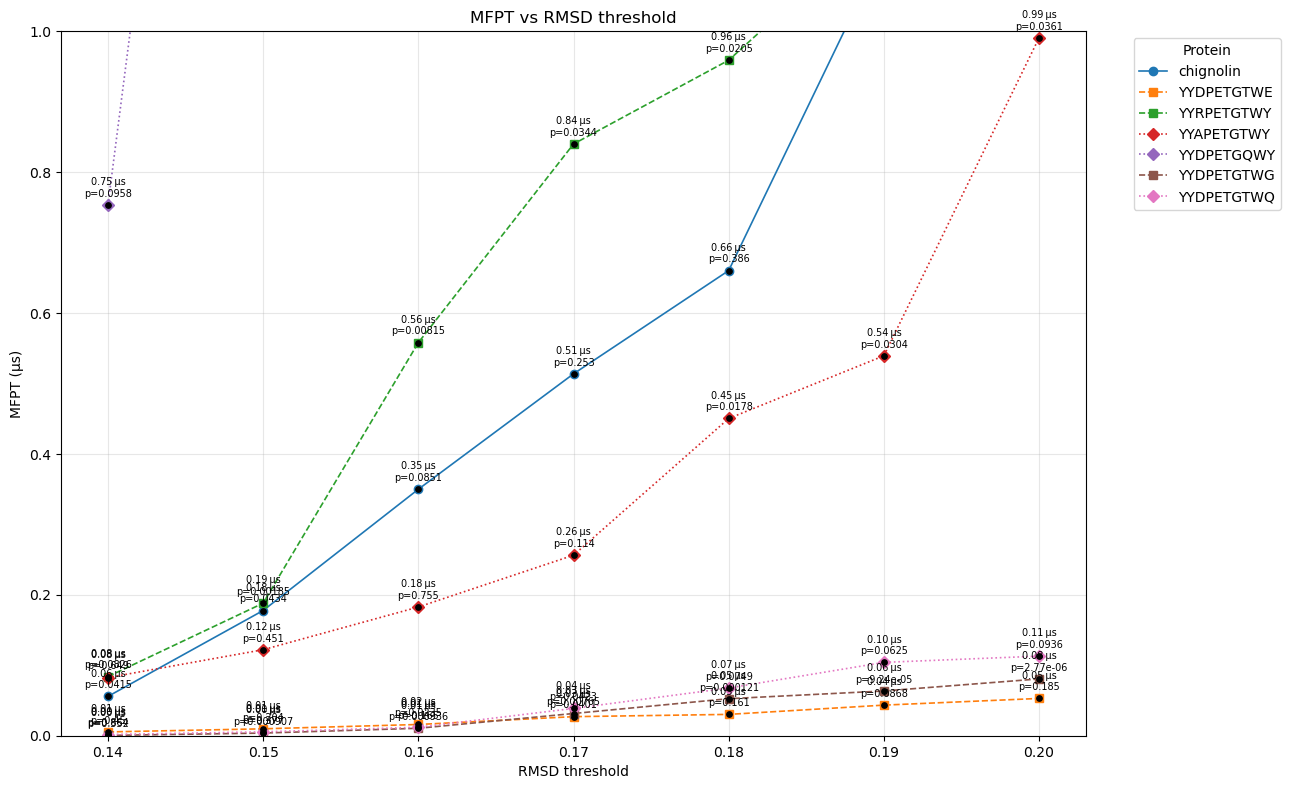

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt



mutation_types = ['ref', 'strong', 'strong', 'weak', 'weak', 'strong', 'weak']
# mutation_types = ['ref', 'strong', 'weak' ]
style_map = {
    'ref': {'linestyle': '-', 'marker': 'o'},
    'strong': {'linestyle': '--', 'marker': 's'},
    'weak': {'linestyle': ':', 'marker': 'D'}
}

fig, ax = plt.subplots(figsize=(13, 8))
estimator = STiMetaD(minSampleSize=5)

for i, protein in enumerate(proteins):
    mt = mutation_types[i]            
    style = style_map[mt]

    mfpt_vals, p_vals = [], []
    for th in thresholds:
        s = np.sort(all_mfpt[protein][th])[:50]
        mfpt, p = estimator.iMetaDMFPT(s, KStest=True)

        mfpt_vals.append(mfpt / 1e6)
        p_vals  .append(p)

    ax.plot(thresholds, mfpt_vals, **style, label=protein, linewidth=1.2)
    ax.scatter(thresholds, mfpt_vals, color='black', s=15, zorder=3)

    for x, y, p in zip(thresholds, mfpt_vals, p_vals):
        ax.annotate(
            f"{y:.2f} µs\np={p:.3g}",
            xy=(x, y),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            fontsize=7,
            color='black'
        )

ax.set_xlabel("RMSD threshold")
ax.set_ylabel("MFPT (µs)")
ax.set_title("MFPT vs RMSD threshold")
ax.grid(alpha=.3)
ax.set_ylim(0, 1)
# ax.set_xlim(0.15, 0.3)
ax.legend(title="Protein", bbox_to_anchor=(1.04, 1), loc="upper left")
fig.tight_layout()


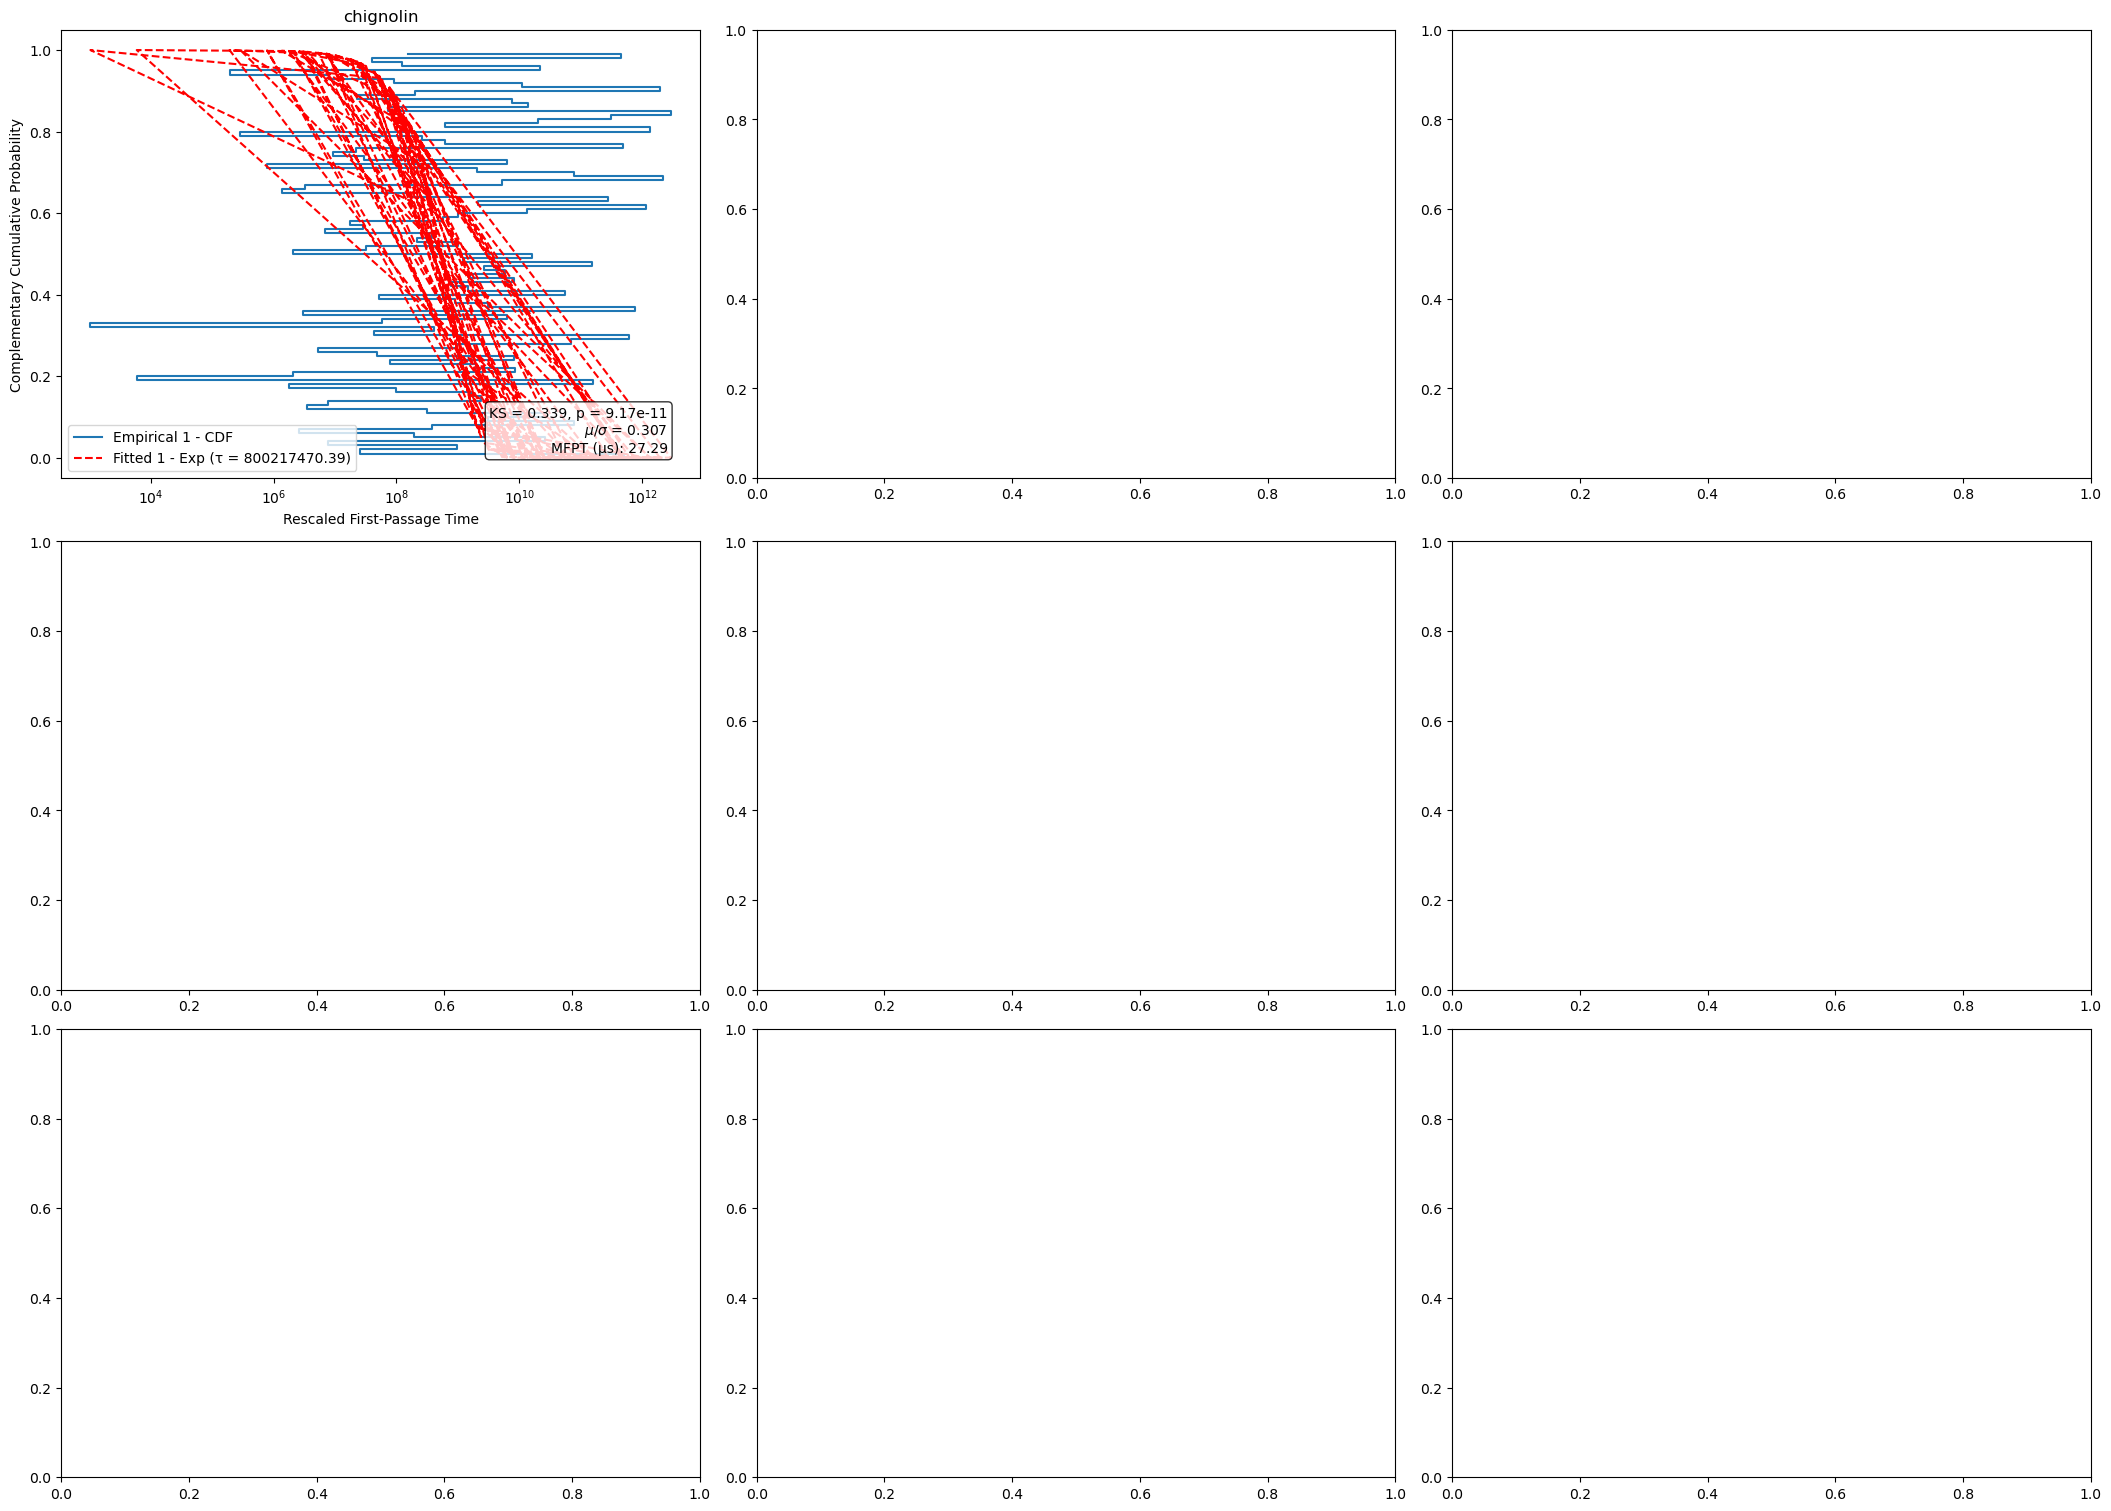

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, kstest
from scipy import optimize

def cumulative_exp(x, tau):
    return 1 - np.exp(-x / tau)

n_cols = 3
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), constrained_layout=True)

for idx, protein in enumerate(proteins):
    row, col = divmod(idx, n_cols)
    ax = axes[col][row]
    ax.set_xscale('log')

    for th in thresholds:
    # samples_sorted = []
             = np.array(all_mfpt[protein][th])

        n = len(predicted)
        CDF = np.arange(1, n + 1) / n 

        tau_fit = optimize.curve_fit(cumulative_exp, predicted, CDF, p0=(np.mean(predicted)))[0][0]
        fitted_CDF = cumulative_exp(predicted, tau_fit)

        ax.step(predicted, 1 - CDF, label="Empirical 1 - CDF", where='post')
        ax.plot(predicted, 1 - fitted_CDF, 'r--', label=f"Fitted 1 - Exp (τ = {tau_fit:.2f})")

        ax.set_title(protein)
        ax.set_xlabel('Rescaled First-Passage Time')
        ax.set_ylabel('Complementary Cumulative Probability')
        ax.legend()

        mu = np.mean(predicted)
        sigma = np.std(predicted)
        mean_std_ratio = mu / sigma

        ks_stat, p_value = kstest(predicted, 'expon', args=(0, tau_fit))

        mfpt_us = estimator.estimateMFPT(samples= predicted) / 1e6

        stats_text = (
            f"KS = {ks_stat:.3f}, p = {p_value:.3g}\n"
            f"$\\mu/\\sigma$ = {mean_std_ratio:.3f}\n"
            f"MFPT (μs): {mfpt_us:.2f}"
        )
        ax.text(0.95, 0.05, stats_text,
                transform=ax.transAxes,
                fontsize=10, va='bottom', ha='right',
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.show()


In [24]:
import numpy as np



median = np.median(samples)
median_meanln2_ratio = median / (mu * np.log(2))
print(f"median / (μ ln 2) = {median_meanln2_ratio:.3f} (should be ≈ 1)")


from scipy.stats import expon, kstest

# Fit exponential (assumes transitions start at t=0)
loc, tau = expon.fit(samples, floc=0)



TypeError: unsupported operand type(s) for /: 'dict' and 'int'